# **Advertising Sales Impact** 📈

**Team 4:** Aylin, Mariana and Dina

## **Library Imports**

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix, roc_curve, auc, classification_report, r2_score

## **Load Dataset**

In [2]:
file_name = "Advertising Budget and Sales.csv"

df = pd.read_csv(file_name).drop(columns=['Unnamed: 0'])

In [3]:
df.head()

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


## **Basic EDA**

In [4]:
df.shape

(200, 4)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TV Ad Budget ($)         200 non-null    float64
 1   Radio Ad Budget ($)      200 non-null    float64
 2   Newspaper Ad Budget ($)  200 non-null    float64
 3   Sales ($)                200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [6]:
df.describe()

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


**First impressions:**

* The dataset is relatively small, containing only 200 entries and 4 column (plus one old index that was removed)
* It only contains float items
* There are no NaN or null entries
* We can see there are minimums on Budget that are very low, nevertheless, the minimum on Sales is not zero, by this we can infer there are some cases where not as much money, or no money at all, was invested in certain areas
* By comparing the mean to the 50% (which is the median), we can tell how "skewed" the data is. In our case, for instance
  * TV and Radio: mean and median are very close. This tells us it holds a normal distribution.
  * Newspaper: mean is higher than the median. This indicates it has a right skew, we think it could likely be caused by a few "expensive" outliers

## **Relationships Visualization**

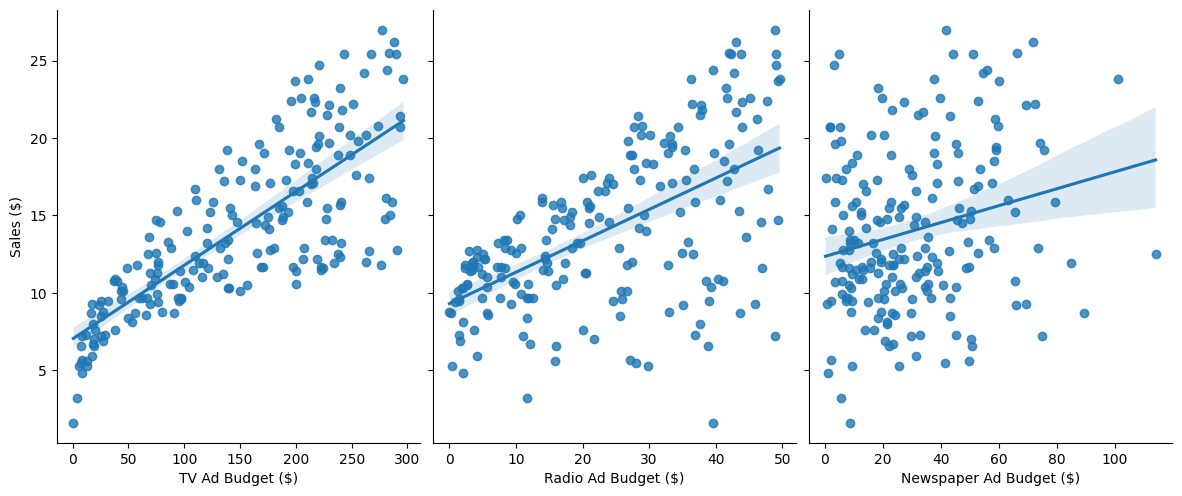

In [7]:
# grid of scatter plots with a linear regression line for each
sns.pairplot(df, x_vars=['TV Ad Budget ($)', 'Radio Ad Budget ($)', 'Newspaper Ad Budget ($)'],
             y_vars='Sales ($)', height=5, aspect=0.8, kind='reg')
plt.show()

Here, we can visualize the steeper the line and the more tightly the dots gather around it, the stronger the correlation to sales. We can see that TV shows the cleanest line in this dataset

## **Linear Regression**

Firts, we split it into a training set (80%) and a testing set (20%).

In [8]:
X = df[['TV Ad Budget ($)', 'Radio Ad Budget ($)', 'Newspaper Ad Budget ($)']]
y = df['Sales ($)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Now we let the computer find the mathematical formula:

$$Sales = \beta_0 + (\beta_1 \cdot TV) + (\beta_2 \cdot Radio) + (\beta_3 \cdot Newspaper)$$

In [9]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


**Determine the Return on Investment (ROI)**

The ROI or coefficients tell us exactly how much sales increase for every $1 spent on a specific channel

In [10]:
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print(coeff_df)

                         Coefficient
TV Ad Budget ($)            0.044730
Radio Ad Budget ($)         0.189195
Newspaper Ad Budget ($)     0.002761


TV has a coefficient of 0.04, it means that for every $100 spent on TV, we can expect around 5 units of sales

The highest number we see is the Radio, this is our most "efficient" channel.

**Model Evaluation (RMSE)**

In order to prove how accurate our model is. We use the R-squared ($R^2$), which tells us how much of the "Sales" variance is explained by our budget.

In [11]:
predictions = model.predict(X_test)
print(f"R-squared: {r2_score(y_test, predictions)}")

R-squared: 0.899438024100912


Our $R^2$ of 0.89 means the ad budgets explain 90% of the sales, which is excellent.

## **Save the Model (The "Pickle" Step)**

In [15]:
joblib.dump(model, 'advertising_model.pkl')

print("Success! Download 'advertising_model.pkl' from the files tab.")

Success! Download 'advertising_model.pkl' from the files tab.


# **Creating the Streamlit Interface**

In [17]:
import streamlit as st
import joblib
import numpy as np

# 1. Load the pre-trained Linear Regression model
model = joblib.load('advertising_model.pkl')

# 2. Set up the Web Page Title
st.set_page_config(page_title="Team 4: Sales Predictor")
st.title("📈 Advertising Sales Impact Predictor")
st.write("Team 4: Aylin, Mariana, and Dina")

st.markdown("""
This app predicts **Total Sales** based on your advertising budget for 
TV, Radio, and Newspapers using a **Linear Regression** model.
""")

# 3. Create an "Optimization Dashboard" using Sliders
# Users can simulate different ad spends 
st.sidebar.header("Adjust Advertising Budgets")

tv = st.sidebar.slider("TV Ad Budget ($)", min_value=0.0, max_value=300.0, value=150.0)
radio = st.sidebar.slider("Radio Ad Budget ($)", min_value=0.0, max_value=50.0, value=25.0)
news = st.sidebar.slider("Newspaper Ad Budget ($)", min_value=0.0, max_value=110.0, value=40.0)

# 4. Perform Prediction
# We arrange the slider values into a 2D array for the model
features = np.array([[tv, radio, news]])
prediction = model.predict(features)

# 5. Display the Results
st.subheader("Prediction Result")
st.metric(label="Predicted Sales Units", value=f"{prediction[0]:.2f}")

# 6. ROI Insight
st.info("""
**Analysis Highlight:** Based on our model coefficients, **Radio** shows a high impact per dollar spent, 
while **TV** shows a strong overall linear correlation with sales.
""")

2026-03-06 13:57:56.005 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 13:57:56.006 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 13:57:56.072 
  command:

    streamlit run /Users/I767484/programming_LAB/dhow_ScientificProgrammingLab/.venv/lib/python3.14/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-03-06 13:57:56.073 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 13:57:56.073 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 13:57:56.073 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 13:57:56.073 Thread 'MainThread': missing Sc

DeltaGenerator()